   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  
Shape: (303, 14)

Data Types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

Summary Statistics:
               age         sex          cp    t

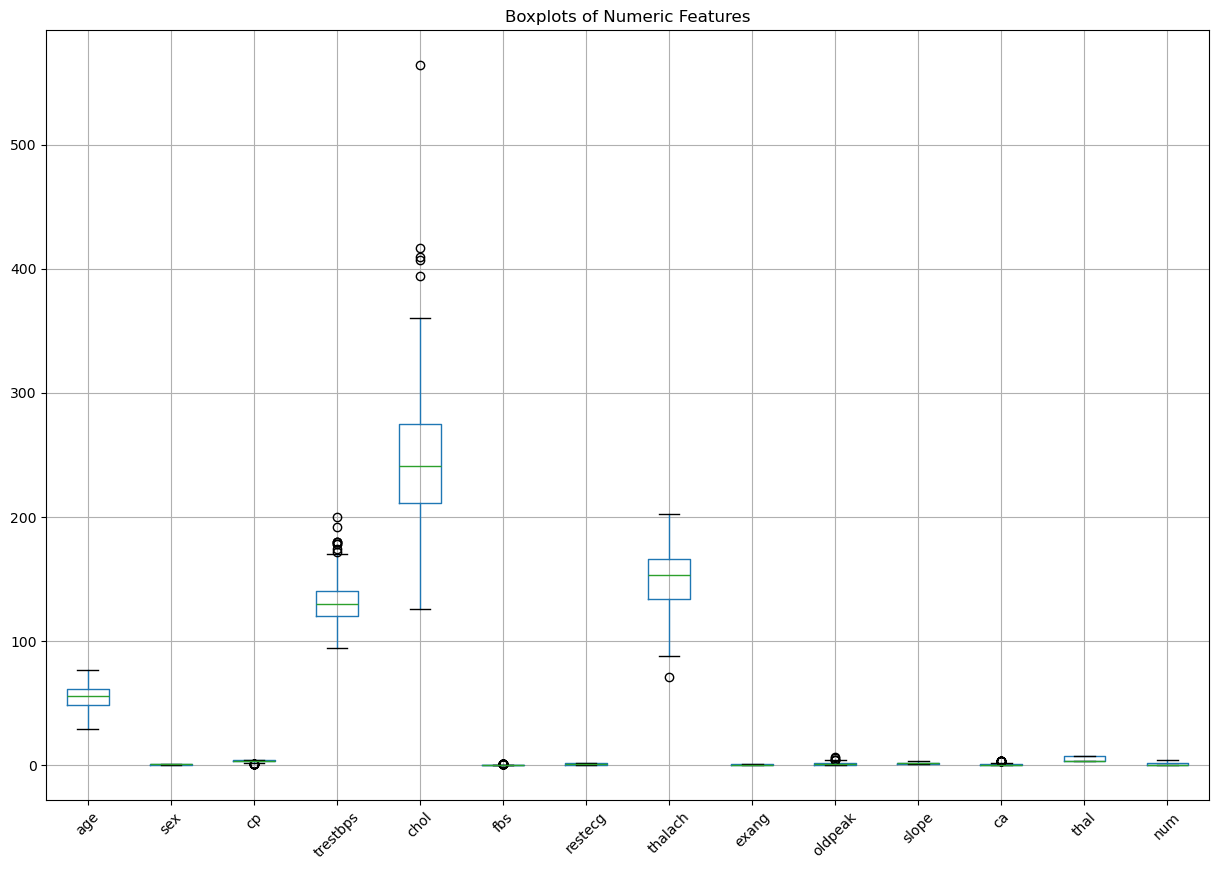

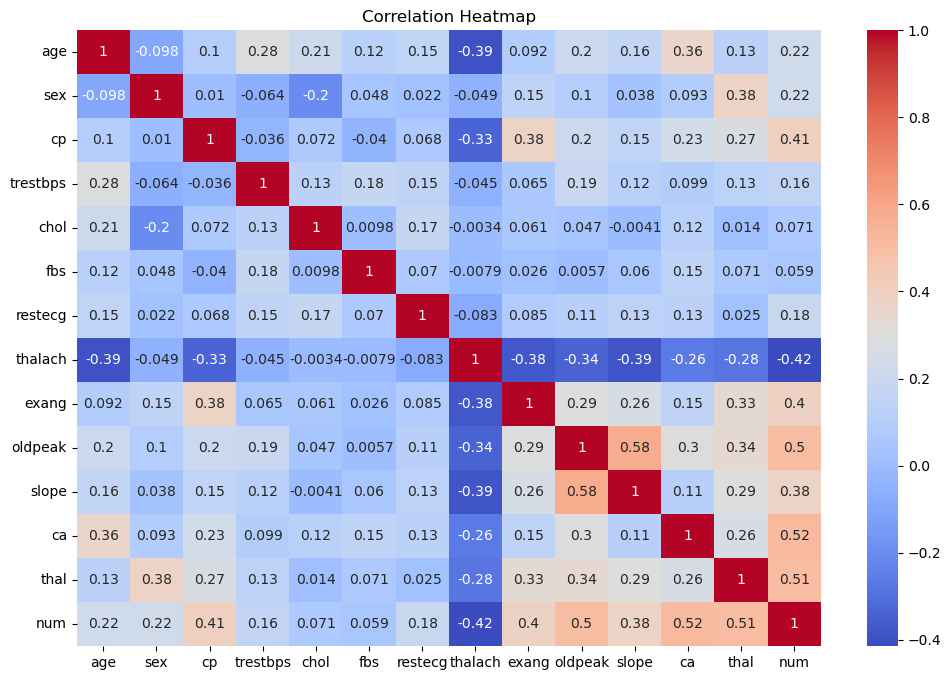

In [8]:
# ============================================================
# STEP 2 - Data Collection & Understanding
# ============================================================

# Using the Heart Disease Dataset (UCI) database.

# ------------------------------------------------------------
#Step 2.1.Summarise feature types, missing values, outliers, etc.
# ------------------------------------------------------------
#
# 1. Load, Inspect, Summarize Feature Types, Missing Values, Outliers
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Download from UCI : UCI: https://archive.ics.uci.edu/static/public/45/data.csv
# heart_disease == df

# Load dataset if it was downloaded 
# df = pd.read_csv("data.csv")   # UCI Heart Disease dataset

# Load dataset
# Load directly from a URL (no download needed)
#url = "https://archive.ics.uci.edu/static/public/45/data.csv"
# Load directly from github - contains the same data as data from the source
url = "https://raw.githubusercontent.com/eschenry/Heart-Disease-ML/refs/heads/main/data/data.csv" 
df = pd.read_csv(url)
print(df.head())


# 1. Basic structure
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

# 2. Summary statistics
print("\nSummary Statistics:\n", df.describe(include='all'))

# 3. Missing values
print("\nMissing Values:\n", df.isnull().sum())

# 4. Identify numeric vs categorical
numeric_features = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

# 5. Outlier detection using IQR
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)][col]

outlier_summary = {col: len(detect_outliers(col)) for col in numeric_features}
print("\nOutlier Counts per Numeric Feature:\n", outlier_summary)

# 6. Boxplots for outlier visualization
plt.figure(figsize=(15,10))
df[numeric_features].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Features")
plt.show()

# 7. Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [10]:
# ------------------------------------------------------------
#Step 2.2. Provide a data dictionary (variables, types, units, allowed values).
# ------------------------------------------------------------
#
#import pandas as pd

# Load dataset
# Load directly from a URL (no download needed)
#url = "https://archive.ics.uci.edu/static/public/45/data.csv"
# Load directly from github - contains the same data as data from the source
url = "https://raw.githubusercontent.com/eschenry/Heart-Disease-ML/refs/heads/main/data/data.csv" 
df = pd.read_csv(url)


# Generate Data Dictionary
# Basic metadata
data_dict = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

print(data_dict)

# Produce a Data Dictionary with Allowed Values

for col in df.columns:
    print(f"\n{'='*50}")
    print(f"Variable: {col}")
    print(f"Type: {df[col].dtype}")
    print(f"Missing Values: {df[col].isnull().sum()}")

    # Display unique values for categorical variables
    if df[col].nunique() <= 10:
        print("Allowed Values:")
        print(sorted(df[col].dropna().unique()))
    else:
        print(f"Range: {df[col].min()} to {df[col].max()}")

          Variable Data Type  Missing Values  Unique Values
age            age     int64               0             41
sex            sex     int64               0              2
cp              cp     int64               0              4
trestbps  trestbps     int64               0             50
chol          chol     int64               0            152
fbs            fbs     int64               0              2
restecg    restecg     int64               0              3
thalach    thalach     int64               0             91
exang        exang     int64               0              2
oldpeak    oldpeak   float64               0             40
slope        slope     int64               0              3
ca              ca   float64               4              4
thal          thal   float64               2              3
num            num     int64               0              5

Variable: age
Type: int64
Missing Values: 0
Range: 29 to 77

Variable: sex
Type: int64
Missing Valu